In [ ]:
# MACHINE LEARNING PROJECT: IUCN RED LIST SPECIES CLASSIFICATION
# Students: Juliette Faurie (572389) & Sei Bayle (572817)
# SDG 13: Climate Action

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import geopandas as gpd
import os
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
# 1. LOADING IUCN DATA
# Download from: https://www.iucnredlist.org/resources/spatial-data-download (Terrestrial Mammals)

from google.colab import drive
import geopandas as gpd
import os

drive.mount('/content/drive')
data_folder = '/content/drive/MyDrive/Universitas Gadjah Mada/Artificial Intelligence/data'

gdf = gpd.read_file(os.path.join(data_folder, "MAMMALS_TERRESTRIAL_ONLY.shp"))

print(gdf.head())

print(gdf.columns)

Mounted at /content/drive
   id_no              sci_name  presence  origin  seasonal  \
0     18  Abrocoma boliviensis         1       1         1   
1    137   Acerodon celebensis         1       1         1   
2    137   Acerodon celebensis         1       1         1   
3    137   Acerodon celebensis         1       1         1   
4    137   Acerodon celebensis         1       1         1   

                                 compiler  yrcompiled  \
0  IUCN SSC Small Mammal Specialist Group        2016   
1                                    IUCN        2022   
2                                    IUCN        2022   
3                                    IUCN        2022   
4                                    IUCN        2022   

                                            citation subspecies subpop  ...  \
0             IUCN SSC Small Mammal Specialist Group       None   None  ...   
1  IUCN (International Union for Conservation of ...       None   None  ...   
2  IUCN (Internationa

In [ ]:
# 2. FEATURE ENGINEERING

# A. Range Size
# Since IUCN shapefiles are mostly geographic ranges, we extract:
# - Range size (area of polygon)
# - Centroid coordinates (as proxy for region)
# - Then we can merge with external datasets

categories_to_drop = ['DD', 'EX', 'EW']
gdf = gdf[~gdf['category'].isin(categories_to_drop)].copy()

# Calculating range size (in km²)
if 'geometry' in gdf.columns:
    # Project to a metric CRS for area calculation
    gdf_projected = gdf.to_crs(epsg=6933)  # Equal area projection
    gdf['range_size_km2'] = gdf_projected.geometry.area / 1e6  # Convert to km²
    gdf['perimeter_km'] = gdf_projected.geometry.length / 1000

    # Getting centroid coordinates
    gdf['centroid_lon'] = gdf.geometry.centroid.x
    gdf['centroid_lat'] = gdf.geometry.centroid.y
    gdf['abs_latitude'] = gdf['centroid_lat'].abs()

# B. Converting Boolean columns to 0/1
# 'terrestrial', “marine” and “freshwater” are often “true”/'false' strings
for col in ['terrestria', 'marine', 'freshwater']:
    gdf[col] = gdf[col].map({'true': 1, 'false': 0, True: 1, False: 0})

# C. Establishment of Target
gdf['target'] = gdf['category'].apply(lambda x: 1 if x in ['VU', 'EN', 'CR'] else 0)

# D. Grouping by species
species_gdf = gdf.groupby('sci_name').agg({
    'range_size_km2': 'sum',
    'perimeter_km': 'sum',
    'centroid_lon': 'mean',
    'centroid_lat': 'mean',
    'abs_latitude': 'mean',
    'terrestria': 'first',
    'marine': 'first',
    'freshwater': 'first',
    'order_': 'first',
    'target': 'first'
}).reset_index()

# E. Feature Engineering final
species_gdf['range_size_log'] = np.log1p(species_gdf['range_size_km2'])
species_gdf['fragmentation_index'] = species_gdf['perimeter_km'] / (species_gdf['range_size_km2'] + 1e-6)
order_dummies = pd.get_dummies(species_gdf['order_'], prefix='order', dtype=int)

# F. Final selection of ‘Features’
base_features = ['range_size_log', 'fragmentation_index', 'centroid_lon', 'abs_latitude', 'terrestria', 'marine', 'freshwater']
X_df = pd.concat([species_gdf[base_features], order_dummies], axis=1)
features = X_df.columns.tolist()

X_raw = X_df.fillna(0).values
y = species_gdf['target'].values

print(f"Shape of X: {X_raw.shape}")

Shape of X: (4921, 33)


In [ ]:
# 3. TRAIN-TEST SPLIT (80-20)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]

np.random.seed(42)
idx_0_downsampled = np.random.choice(idx_0, size=len(idx_1), replace=False)
balanced_indices = np.concatenate([idx_1, idx_0_downsampled])

X_train_balanced = X_train_raw[balanced_indices]
y_train_balanced = y_train[balanced_indices]

means = np.mean(X_train_balanced, axis=0)
stds = np.std(X_train_balanced, axis=0)
stds[stds == 0] = 1e-8

X_train = (X_train_balanced - means) / stds
X_test = (X_test_raw - means) / stds

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training set: 2054 samples
Test set: 985 samples
Training class distribution: [2909 1027]
Test class distribution: [728 257]


In [ ]:
# 4. LOGISTIC REGRESSION

class LogisticRegression:
    def __init__(self, learning_rate, n_iterations, lambda_param=0.1):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.lambda_param = lambda_param
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        """Sigmoid function - squashes values between 0 and 1"""
        # Clipping to avoid overflow errors
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        """Training using gradient descent"""
        n_samples, n_features = X.shape

        # Initializing weights to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient descent loop
        for iteration in range(self.n_iterations):
            # Forward pass
            linear_pred = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_pred)

            n_pos = np.sum(y)
            n_neg = len(y) - n_pos
            w_pos = n_neg / (n_pos + n_neg)
            w_neg = n_pos / (n_pos + n_neg)

            sample_weights = np.where(y == 1, w_pos, w_neg)

            dw = (1/n_samples) * np.dot(X.T, sample_weights * (y_pred - y)) + (self.lambda_param / n_samples) * self.weights
            db = (1/n_samples) * np.sum(sample_weights * (y_pred - y))

            # Updating parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        """Making predictions (0 or 1)"""
        linear_pred = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_pred)
        return (y_pred >= 0.3).astype(int)

    def predict_proba(self, X):
        """Getting probability scores"""
        linear_pred = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_pred)

In [ ]:
# 5. TRAINING THE MODEL

model = LogisticRegression(learning_rate=0.1, n_iterations=8000, lambda_param=0.1)
model.fit(X_train, y_train_balanced)

# Making predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)

print(f"Weights: {model.weights}")
print(f"Bias: {model.bias:.4f}")

Training completed after 8000 iterations
Weights: [-2.19497146e+00  2.70303443e-01  8.90337841e-02  8.83461684e-02
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.87787421e-01
  3.58078249e-01  3.94217258e-01 -6.68741187e-02  6.85289601e-02
 -1.34144078e-01 -9.24629200e-02 -6.21806753e-02 -5.88609320e-02
 -4.17535273e-01  0.00000000e+00 -5.48738141e-04 -1.04270166e-01
 -1.85882587e-01  2.16337723e-01  0.00000000e+00  1.61097816e-01
  3.32387994e-02  1.53193918e-01  4.80100488e-01  8.61728328e-02
  7.62713238e-01  1.81774633e-01 -6.18750061e-01 -8.25798779e-02
 -5.87990484e-02]
Bias: 0.1879


In [ ]:
# 6. EVALUATION METRICS

def accuracy(y_true, y_pred):
    """Simple accuracy"""
    return np.mean(y_true == y_pred)

def precision_recall_f1(y_true, y_pred, pos_label=1):
    """Computing precision, recall, F1"""
    TP = np.sum((y_true == pos_label) & (y_pred == pos_label))
    FP = np.sum((y_true != pos_label) & (y_pred == pos_label))
    FN = np.sum((y_true == pos_label) & (y_pred != pos_label))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1

def confusion_matrix(y_true, y_pred):
    """Building confusion matrix"""
    cm = np.zeros((2,2), dtype=int)
    cm[0,0] = np.sum((y_true == 0) & (y_pred == 0))
    cm[0,1] = np.sum((y_true == 0) & (y_pred == 1))
    cm[1,0] = np.sum((y_true == 1) & (y_pred == 0))
    cm[1,1] = np.sum((y_true == 1) & (y_pred == 1))
    return cm

# Computing all metrics
train_acc = accuracy(y_train_balanced, y_pred_train)
test_acc = accuracy(y_test, y_pred_test)

test_precision, test_recall, test_f1 = precision_recall_f1(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)

print("RESULTS")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")
print(f"\nConfusion Matrix:")
print(cm)

RESULTS
Train Accuracy: 0.8043
Test Accuracy:  0.7624
Test Precision: 0.5251
Test Recall:    0.9377
Test F1-Score:  0.6732

Confusion Matrix:
[[510 218]
 [ 16 241]]


In [ ]:
# 7. K-FOLD CROSS-VALIDATION
# Doing this to make sure the model is not just lucky with one split

def k_fold_cv(X, y, k=5, random_state=42):
    """K-fold CV implementation"""
    indices = np.arange(X.shape[0])
    np.random.seed(random_state)
    np.random.shuffle(indices)

    fold_size = len(indices) // k
    accuracies = []

    for i in range(k):
        # Splitting
        val_start = i * fold_size
        val_end = (i + 1) * fold_size if i < k-1 else len(indices)

        val_idx = indices[val_start:val_end]
        train_idx = np.concatenate([indices[:val_start], indices[val_end:]])

        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        # Training on this fold
        model_fold = LogisticRegression(learning_rate=0.1, n_iterations=2000)
        model_fold.fit(X_tr, y_tr)
        y_pred_fold = model_fold.predict(X_val)
        accuracies.append(accuracy(y_val, y_pred_fold))

    return np.mean(accuracies), np.std(accuracies)

cv_mean, cv_std = k_fold_cv(X_train, y_train_balanced, k=5)
print(f"\n5-Fold CV Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")

Training completed after 2000 iterations
Training completed after 2000 iterations
Training completed after 2000 iterations
Training completed after 2000 iterations
Training completed after 2000 iterations

5-Fold CV Accuracy: 0.8018 ± 0.0237


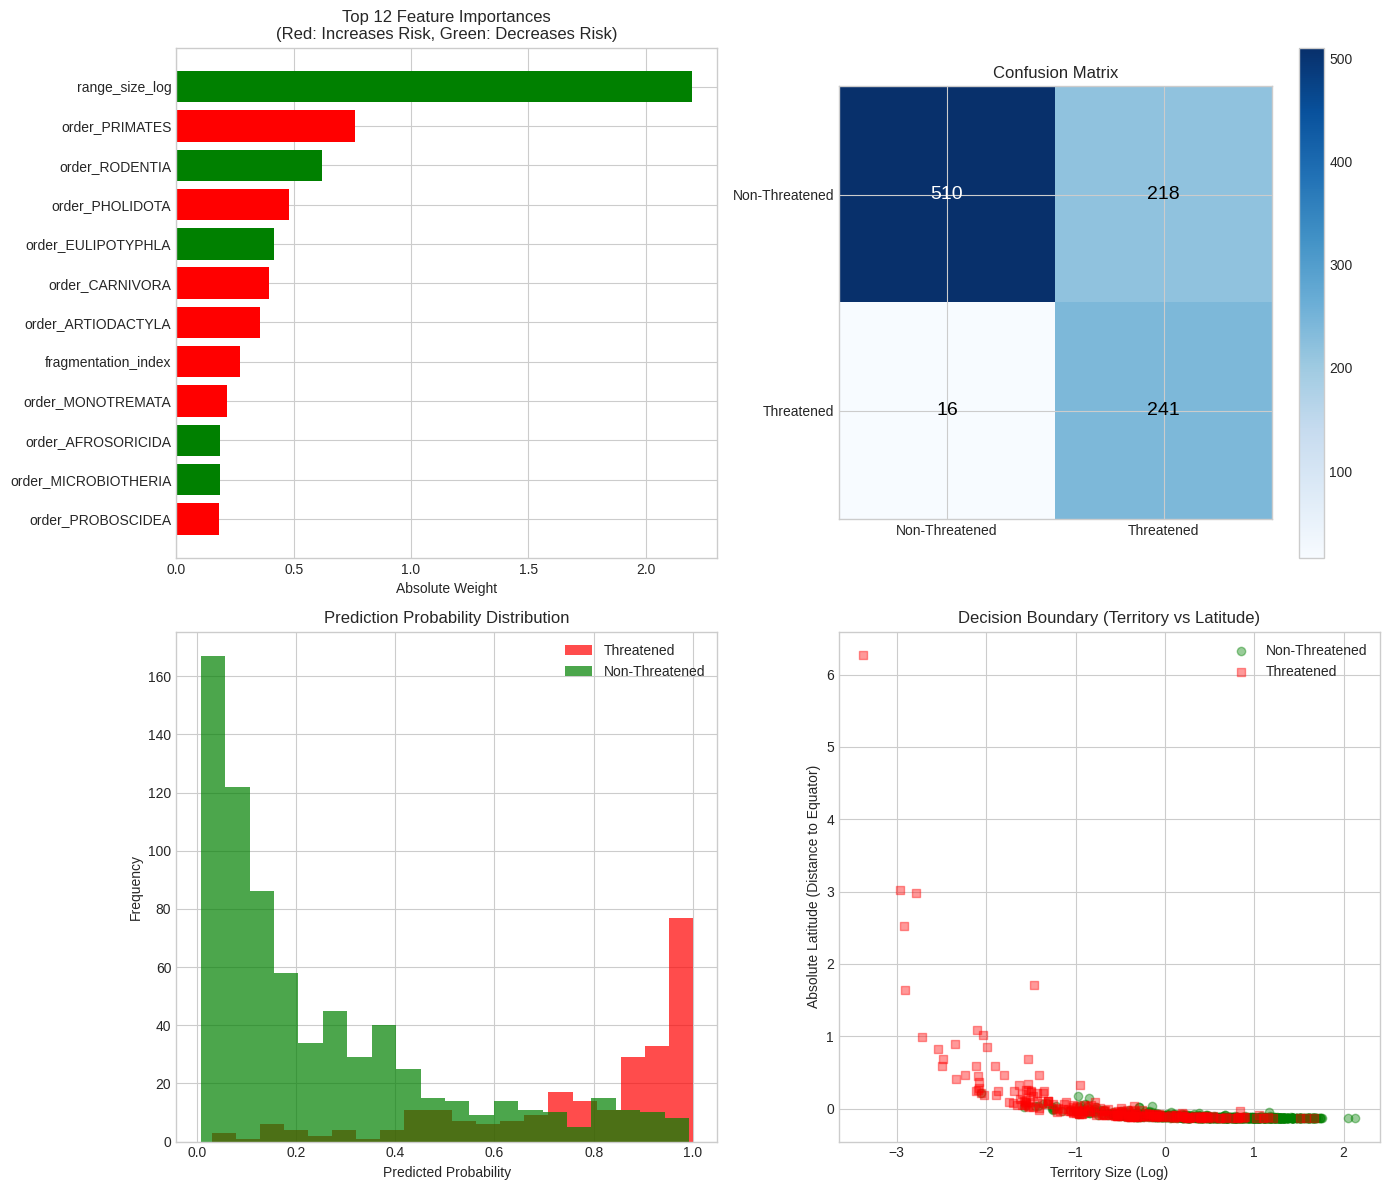


Plots saved to results.png


In [ ]:
# 8. VISUALIZATIONS

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Feature importance
ax1 = axes[0, 0]
feature_importance = np.abs(model.weights)
importance_df = pd.DataFrame({
    'feature': features,
    'importance': feature_importance,
    'weight_sign': model.weights
}).sort_values('importance', ascending=True)

top_features = importance_df.tail(12)

# Red: increase risk, green: decreases risk
colors = ['red' if w > 0 else 'green' for w in top_features['weight_sign']]

ax1.barh(top_features['feature'], top_features['importance'], color=colors)
ax1.set_title('Top 12 Feature Importances\n(Red: Increases Risk, Green: Decreases Risk)')
ax1.set_xlabel('Absolute Weight')

# Plot 2: Confusion Matrix
ax2 = axes[0, 1]
im = ax2.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax2.set_title('Confusion Matrix')
plt.colorbar(im, ax=ax2)
tick_marks = np.arange(2)
ax2.set_xticks(tick_marks)
ax2.set_yticks(tick_marks)
ax2.set_xticklabels(['Non-Threatened', 'Threatened'])
ax2.set_yticklabels(['Non-Threatened', 'Threatened'])
# Adding numbers in the cells
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)

# Plot 3: Probability distribution
ax3 = axes[1, 0]
threatened_proba = y_proba_test[y_test == 1]
non_threatened_proba = y_proba_test[y_test == 0]
ax3.hist(threatened_proba, bins=20, alpha=0.7, label='Threatened', color='red')
ax3.hist(non_threatened_proba, bins=20, alpha=0.7, label='Non-Threatened', color='green')
ax3.set_xlabel('Predicted Probability')
ax3.set_ylabel('Frequency')
ax3.set_title('Prediction Probability Distribution')
ax3.legend()

# Plot 4: 2D scatter
ax4 = axes[1, 1]
idx1, idx2 = 0, 1
ax4.scatter(X_test[y_test==0, idx1], X_test[y_test==0, idx2],
           c='green', marker='o', label='Non-Threatened', alpha=0.4)
ax4.scatter(X_test[y_test==1, idx1], X_test[y_test==1, idx2],
           c='red', marker='s', label='Threatened', alpha=0.4)
ax4.set_xlabel('Territory Size (Log)')
ax4.set_ylabel('Absolute Latitude (Distance to Equator)')
ax4.set_title('Decision Boundary (Territory vs Latitude)')
ax4.legend()

plt.tight_layout()
plt.savefig('results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlots saved to results.png")